# Plot the results of the T cell parameter estimations with different extinction thresholds

Generates Figure S9.

It requires that the parameter estimation has been completed for the three extinction thresholds, the top 100 parameter combinations exist, and there exists a file with those results. These files can be created by running runner_t.py with config files with the different extinction thresholds and using the analyze_t.ipynb notebook to get the best parameter combinations for each. Edit the location of those files below.

## Load required packages

In [1]:
%matplotlib widget
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import os
import seaborn as sns
from estimator import Estimator

## User-defined parameters

In [2]:
figure_save_path = "figures/" # Set to None to not save figures
best_value_save_path = "bests/" # Set to None to not save

## Plot distributions of parameters across groups

In [4]:
bests_005 = pd.read_csv("bests/t_100_ext_005.csv")
bests_005["ext_thresh"] = "0.5%"
bests_01 = pd.read_csv("bests/t_100.csv")
bests_01["ext_thresh"] = "1%"
bests_02 = pd.read_csv("bests/t_100_ext_02.csv")
bests_02["ext_thresh"] = "2%"
bests = pd.concat([bests_005, bests_01, bests_02])
bests = bests.drop(["Unnamed: 0"], axis=1)
bests

,group,id,g1,g11,m,k,c,a,f,b,l,error,winner,log_error,ext_thresh
0,Grp. A1 B6 (100% C1),424,0.166,0.000,0.000,0.000,0.04,1.9,1.7,0.03,0.01,281.85254,0,5.641384,0.5%
1,Grp. A1 B6 (100% C1),424,0.166,0.000,0.000,0.000,0.16,0.5,0.3,0.03,0.01,358.71860,0,5.882538,0.5%
2,Grp. A1 B6 (100% C1),424,0.171,0.000,0.000,0.000,0.08,1.5,1.2,0.05,0.01,453.18750,0,6.116306,0.5%
3,Grp. A1 B6 (100% C1),424,0.171,0.000,0.000,0.000,0.18,0.4,0.3,0.02,0.01,468.28534,0,6.149078,0.5%
4,Grp. A1 B6 (100% C1),424,0.171,0.000,0.000,0.000,0.12,1.2,1.2,0.03,0.01,495.16666,0,6.204894,0.5%
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3095,Grp. A4 B6 (20% C1; 80% C11),697,0.166,0.127,-0.060,0.565,0.98,0.2,0.1,0.01,0.01,5642.28760,1,8.638045,2%
3096,Grp. A4 B6 (20% C1; 80% C11),697,0.166,0.127,-0.085,0.175,0.20,0.9,0.5,0.06,0.01,5651.87600,1,8.639743,2%
3097,Grp. A4 B6 (20% C1; 80% C11),697,0.166,0.127,-0.080,0.165,0.14,1.3,1.1,0.04,0.01,5671.58500,1,8.643224,2%
3098,Grp. A4 B6 (20% C1; 80% C11),697,0.166,0.127,-0.085,0.175,0.16,1.2,1.0,0.04,0.01,5682.99270,1,8.645233,2%


In [5]:
bests.loc[bests["group"]=="Grp. A1 B6 (100% C1)", "group"] = "A1"
bests.loc[bests["group"]=="Grp. A2 B6 (80% C1; 20% C11)", "group"] = "A2"
bests.loc[bests["group"]=="Grp. A3 B6 (50% C1; 50% C11)", "group"] = "A3"
bests.loc[bests["group"]=="Grp. A4 B6 (20% C1; 80% C11)", "group"] = "A4"

In [6]:
bests["logaf"] = np.log(bests["a"]/bests["f"])
bests["logbc"] = np.log(bests["b"]/bests["c"])
bests["logkm"] = np.log(bests["k"]/np.abs(bests["m"]))
bests["group_ext"] = bests["group"] + "_" + bests["ext_thresh"]
bests = bests.reset_index(drop=True)

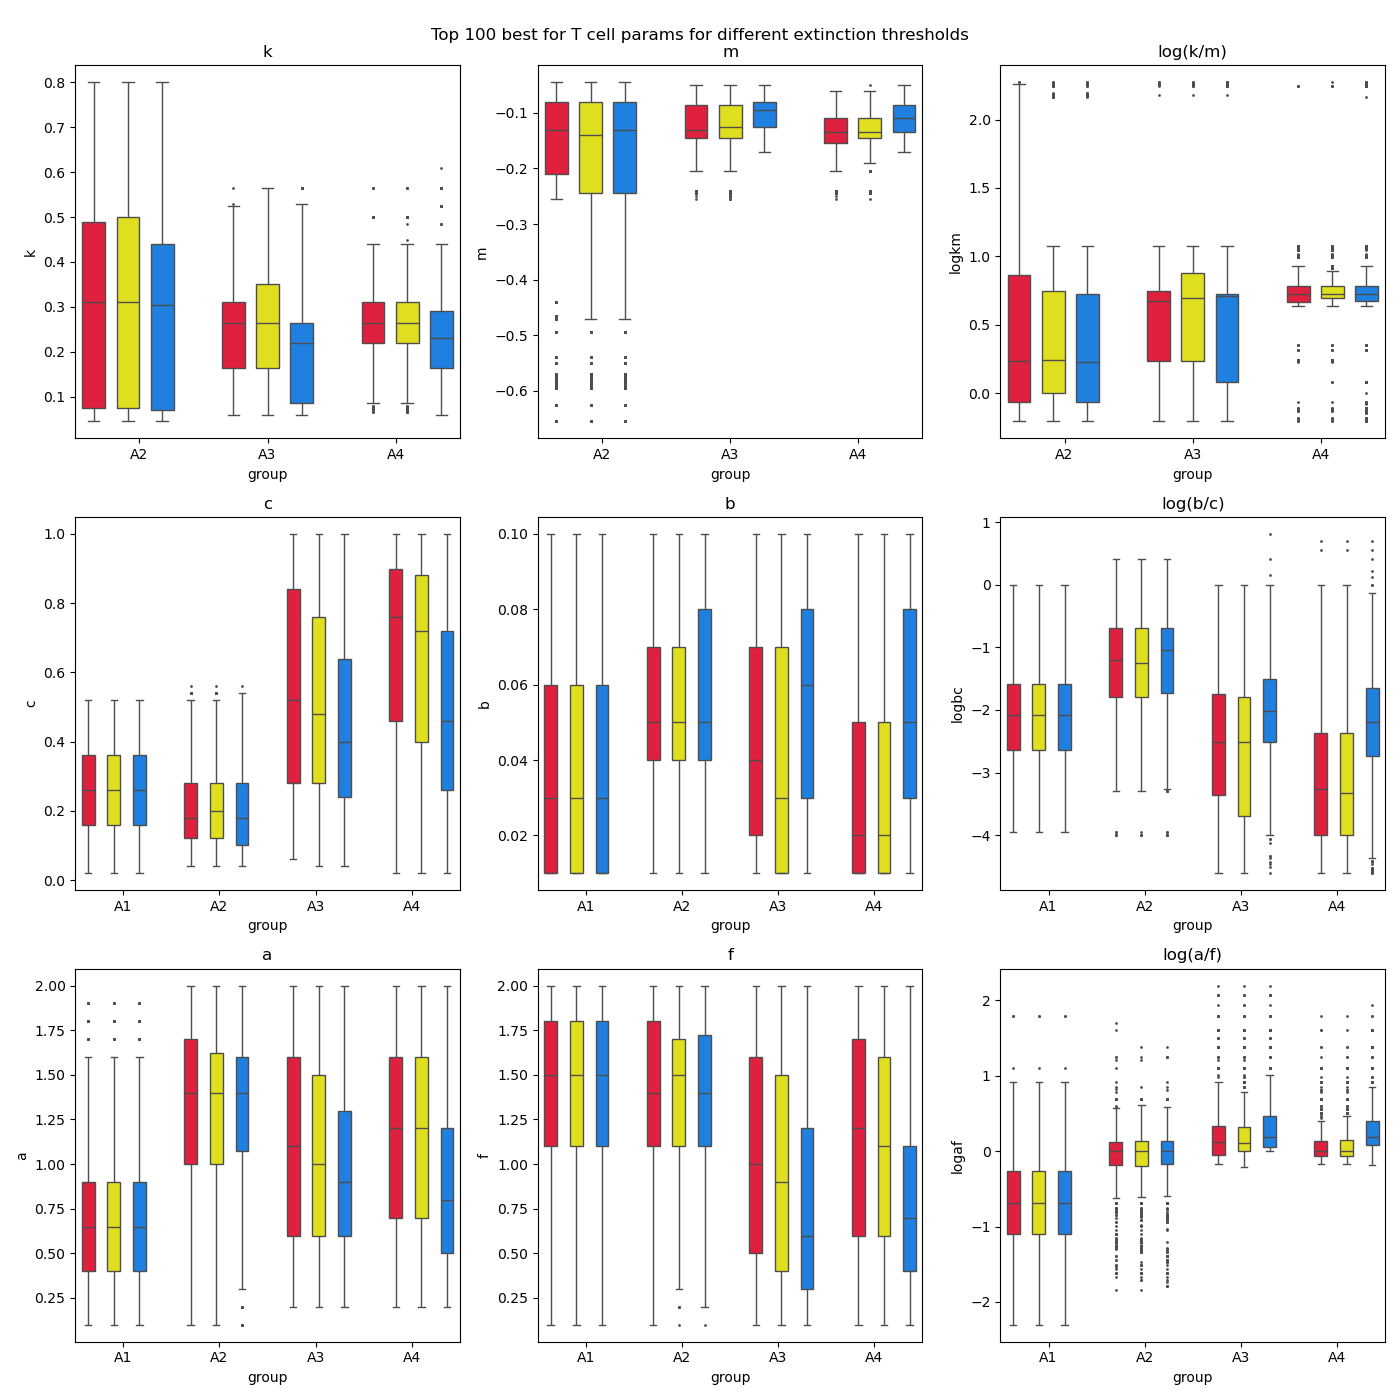

In [8]:
colors3 = ["#ff002a", "#ff002a", "#ff002a", "#ffff00", "#ffff00", "#ffff00", "#0080ff", "#0080ff", "#0080ff"]
colors4 = ["#ff002a", "#ff002a", "#ff002a", "#ff002a", "#ffff00", "#ffff00", "#ffff00", "#ffff00", "#0080ff", "#0080ff", "#0080ff", "#0080ff"]

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(14,14))
sns.boxplot(bests[bests["group"]!="A1"], x="group", y="k", hue="group_ext", fliersize=1, gap=-1, palette=colors3, legend=False, ax=axes[0][0])
axes[0][0].set_title("k")
sns.boxplot(bests[bests["group"]!="A1"], x="group", y="m", hue="group_ext", fliersize=1, gap=-1, palette=colors3, legend=False, ax=axes[0][1])
axes[0][1].set_title("m")
sns.boxplot(bests[bests["group"]!="A1"], x="group", y="logkm", hue="group_ext", fliersize=1, gap=-1, palette=colors3, legend=False, ax=axes[0][2])
axes[0][2].set_title("log(k/m)")
sns.boxplot(bests, x="group", y="c", hue="group_ext", fliersize=1, gap=-1, palette=colors4, legend=False, ax=axes[1][0])
axes[1][0].set_title("c")
sns.boxplot(bests, x="group", y="b", hue="group_ext", fliersize=1, gap=-1, palette=colors4, legend=False, ax=axes[1][1])
axes[1][1].set_title("b")
sns.boxplot(bests, x="group", y="logbc", hue="group_ext", fliersize=1, gap=-1, palette=colors4, legend=False, ax=axes[1][2])
axes[1][2].set_title("log(b/c)")
sns.boxplot(bests, x="group", y="a", hue="group_ext", fliersize=1, gap=-1, palette=colors4, legend=False, ax=axes[2][0])
axes[2][0].set_title("a")
sns.boxplot(bests, x="group", y="f", hue="group_ext", fliersize=1, gap=-1, palette=colors4, legend=False, ax=axes[2][1])
axes[2][1].set_title("f")
sns.boxplot(bests, x="group", y="logaf", hue="group_ext", fliersize=1, gap=-1, palette=colors4, legend=False, ax=axes[2][2])
axes[2][2].set_title("log(a/f)")
plt.suptitle("Top 100 best for T cell params for different extinction thresholds")
plt.tight_layout()
if figure_save_path:
    plt.savefig(figure_save_path+"b6_boxplots_ext_thresh.svg")
plt.show()

In [35]:
plt.close("all")